In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_angle

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

In [5]:
dag_path        = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit"
globalfit_path = f"{dag_path}/globalfit/datasets_v2"

scan_dir_dict = {
    # --- Globalfit ---

    # SPL
    "globalfit_double_no_hybrid_SPL_nosyst_Poisson":        f"{globalfit_path}/Poisson/globalfit_double_no_hybrid_SPL_nosyst",
    "globalfit_double_no_hybrid_nohese_SPL_nosyst_Poisson": f"{globalfit_path}/Poisson/globalfit_double_no_hybrid_nohese_SPL_nosyst",

    "globalfit_double_no_hybrid_SPL_Poisson":        f"{globalfit_path}/Poisson/globalfit_double_no_hybrid_SPL",
    "globalfit_double_no_hybrid_nohese_SPL_Poisson": f"{globalfit_path}/Poisson/globalfit_double_no_hybrid_nohese_SPL",

    "globalfit_double_no_hybrid_SPL_SAY":        f"{globalfit_path}/SAY/globalfit_double_no_hybrid_SPL",
    "globalfit_double_no_hybrid_nohese_SPL_SAY": f"{globalfit_path}/SAY/globalfit_double_no_hybrid_nohese_SPL",

    # BPL
    "globalfit_double_no_hybrid_BPL_noinel_nosyst_Poisson":        f"{globalfit_path}/Poisson/globalfit_double_no_hybrid_BPL_noinel_nosyst",

    "globalfit_double_no_hybrid_BPL_noinel_nosyst_SAY":        f"{globalfit_path}/SAY/globalfit_double_no_hybrid_BPL_noinel_nosyst_minimizer_hybrid",
    
    "globalfit_double_no_hybrid_BPL_noinel_SAY":        f"{globalfit_path}/SAY/globalfit_double_no_hybrid_BPL_noinel_minimizer_hybrid_nlight_20",
    
}

In [4]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/presentations/2026-04-08_diffuse_update/globalfit"
os.system(f"mkdir -p {plotting_path}")

0

In [8]:
# load the data
N_grid = 40 # 20 was standard
drop_unsuccessful = False
scan_dict = {}
data = {}
for name, scan_dir in scan_dir_dict.items():
    print(name)
    print(scan_dir)
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name] = {}
    if "newflavorparam" in name or "gf" in name:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points_angle(scan_dict,name)
    else:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points(scan_dict,name, N_grid=N_grid)


globalfit_double_no_hybrid_SPL_nosyst_Poisson
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/Poisson/globalfit_double_no_hybrid_SPL_nosyst
removed stuff
globalfit_double_no_hybrid_nohese_SPL_nosyst_Poisson
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/Poisson/globalfit_double_no_hybrid_nohese_SPL_nosyst
removed stuff
globalfit_double_no_hybrid_SPL_Poisson
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/Poisson/globalfit_double_no_hybrid_SPL
removed stuff
globalfit_double_no_hybrid_nohese_SPL_Poisson
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/Poisson/globalfit_double_no_hybrid_nohese_SPL
removed stuff
globalfit_double_no_hybrid_SPL_SAY
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/datasets_v2/SAY/globalfit_double_no_hybrid_

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


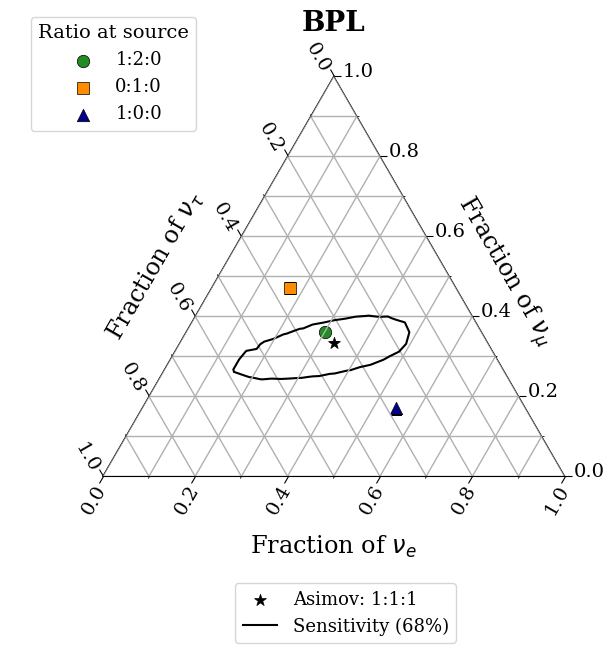

In [9]:
names = [
"globalfit_double_no_hybrid_BPL_noinel_SAY",
]
labels = [
    "Sensitivity",
]

C = plot_contour( data = data,
                  name = names[0],
                  label = labels[0],
                  levels = ["68%"],
                  title = r"BPL",
                  scenarios=True,
                  show_ts_labels=False,
                  savepath = f"{plotting_path}/globalfit_double_no_hybrid_BPL_noinel_SAY.png")


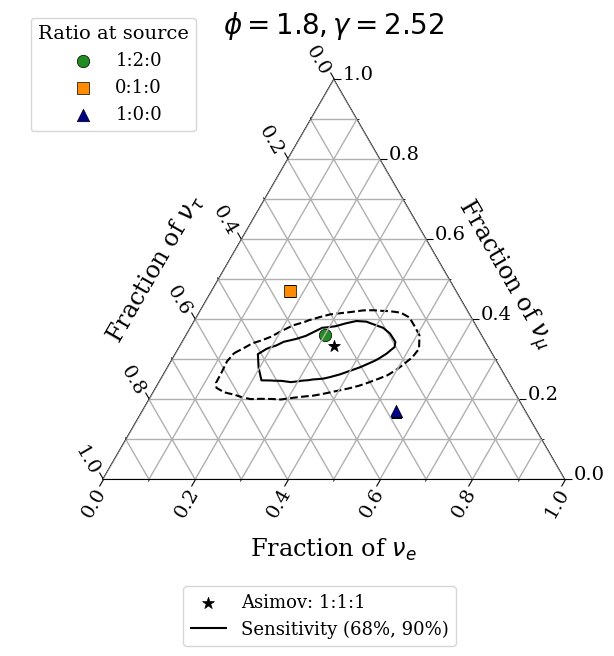

In [10]:
names = [
"globalfit_double_no_hybrid_SPL_SAY",
]
labels = [
    "Sensitivity",
]

C = plot_contour( data = data,
                  name = names[0],
                  label = labels[0],
                  levels = ["68%", "90%"],
                  title = r"$\phi=1.8,\gamma=2.52$",
                  scenarios=True,
                  show_ts_labels=False,
                  savepath = f"{plotting_path}/globalfit_double_no_hybrid_SPL_SAY.png")


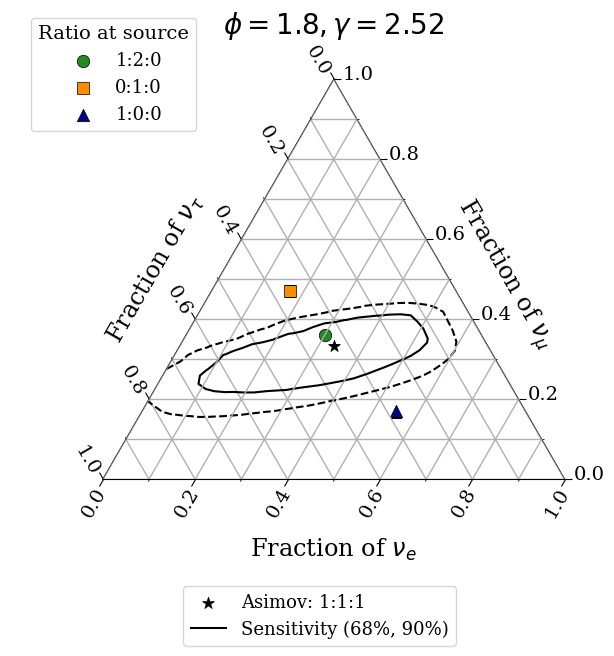

In [11]:
names = [
"globalfit_double_no_hybrid_nohese_SPL_SAY",
]
labels = [
    "Sensitivity",
]

C = plot_contour( data = data,
                  name = names[0],
                  label = labels[0],
                  levels = ["68%", "90%"],
                  title = r"$\phi=1.8,\gamma=2.52$",
                  scenarios=True,
                  show_ts_labels=False,
                  savepath = f"{plotting_path}/globalfit_double_no_hybrid_nohese_SPL_SAY.png")


Comparisons

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()


Area ratio (globalfit_double_no_hybrid_BPL_noinel_nosyst_SAY / globalfit_double_no_hybrid_BPL_noinel_nosyst_SAY) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_BPL_noinel_SAY / globalfit_double_no_hybrid_BPL_noinel_nosyst_SAY) at 68%: 1.0339


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()


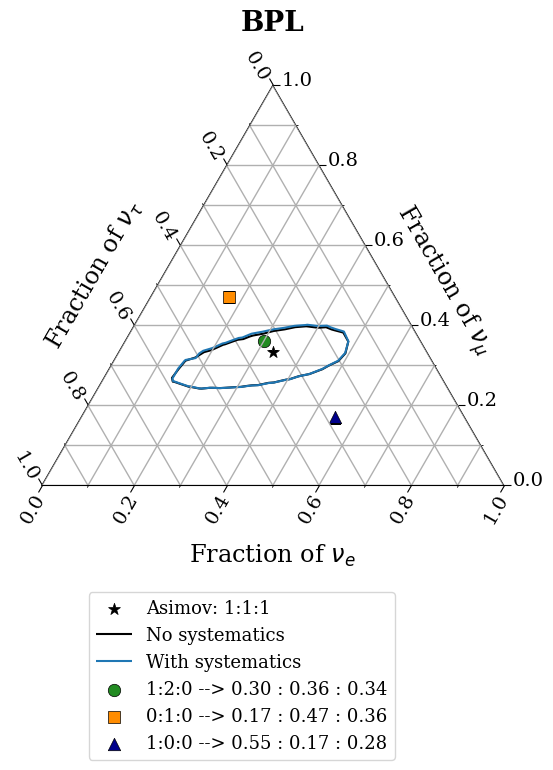

In [14]:
# compare_syst_globalfit_double_no_hybrid_BPL_noinel_SAY
names = [
"globalfit_double_no_hybrid_BPL_noinel_nosyst_SAY",
"globalfit_double_no_hybrid_BPL_noinel_SAY",
]
labels = [
    "No systematics",
    "With systematics",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"BPL",
                  scenarios = True,
                  savepath = f"{plotting_path}/compare_syst_globalfit_double_no_hybrid_BPL_noinel_SAY.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_BPL_noinel_nosyst_SAY", levels=["68%"] )

Area ratio (globalfit_double_no_hybrid_BPL_noinel_nosyst_Poisson / globalfit_double_no_hybrid_BPL_noinel_nosyst_Poisson) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_BPL_noinel_nosyst_SAY / globalfit_double_no_hybrid_BPL_noinel_nosyst_Poisson) at 68%: 1.1220


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

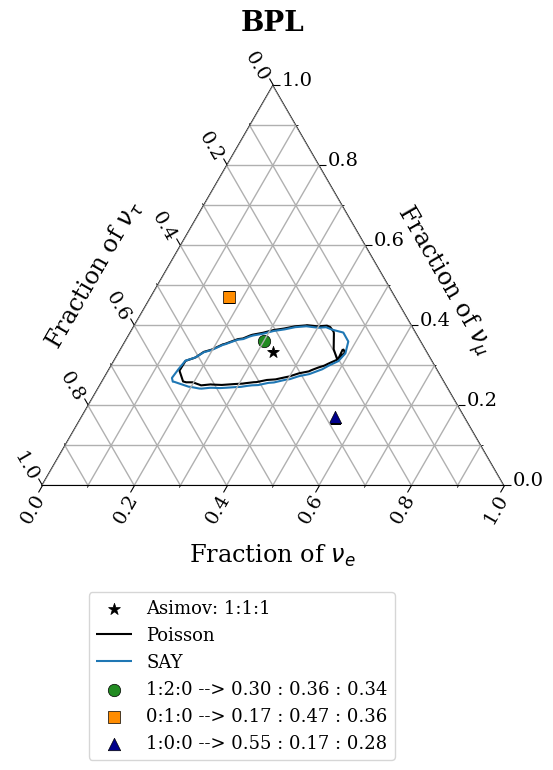

In [15]:
# compare_lik_globalfit_double_no_hybrid_BPL_noinel_SAY
names = [
"globalfit_double_no_hybrid_BPL_noinel_nosyst_Poisson",
"globalfit_double_no_hybrid_BPL_noinel_nosyst_SAY",
]
labels = [
    "Poisson",
    "SAY",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"BPL",
                  scenarios = True,
                  savepath = f"{plotting_path}/compare_lik_globalfit_double_no_hybrid_BPL_noinel_SAY.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_BPL_noinel_nosyst_Poisson", levels=["68%"] )

Area ratio (globalfit_double_no_hybrid_SPL_Poisson / globalfit_double_no_hybrid_SPL_Poisson) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_SPL_SAY / globalfit_double_no_hybrid_SPL_Poisson) at 68%: 0.9059


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

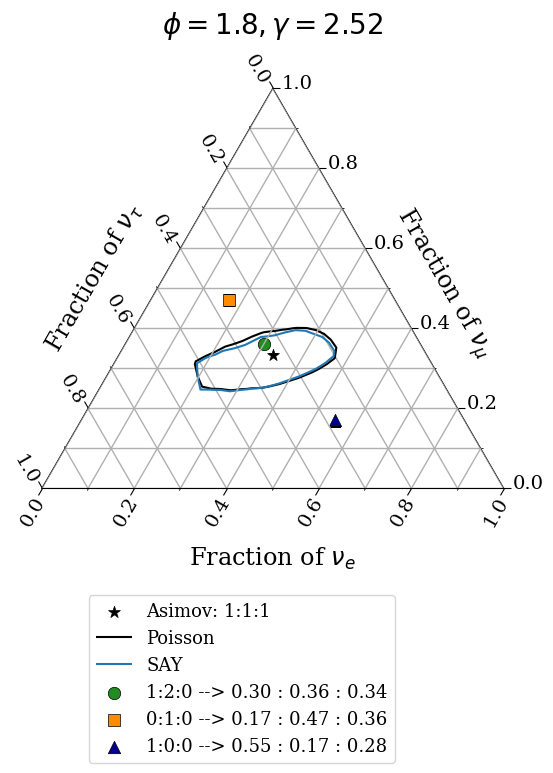

In [20]:
# compare_lik_globalfit_double_no_hybrid_SPL
names = [
"globalfit_double_no_hybrid_SPL_Poisson",
"globalfit_double_no_hybrid_SPL_SAY",
]
labels = [
    "Poisson",
    "SAY",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi=1.8,\gamma=2.52$",
                  scenarios = True,
                  savepath = f"{plotting_path}/compare_lik_globalfit_double_no_hybrid_SPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_SPL_Poisson", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (globalfit_double_no_hybrid_SPL_nosyst_Poisson / globalfit_double_no_hybrid_SPL_nosyst_Poisson) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_SPL_Poisson / globalfit_double_no_hybrid_SPL_nosyst_Poisson) at 68%: 1.0387


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

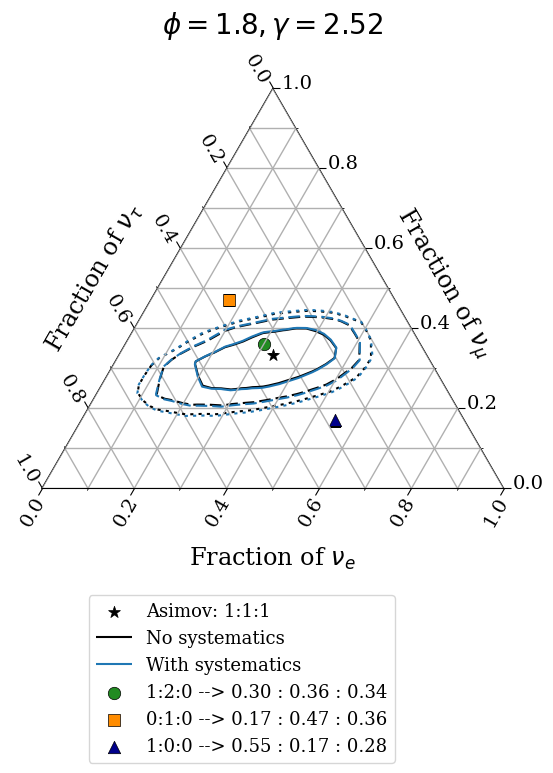

In [19]:
# compare_syst_globalfit_double_no_hybrid_SPL_Poisson
names = [
"globalfit_double_no_hybrid_SPL_nosyst_Poisson",
"globalfit_double_no_hybrid_SPL_Poisson",
]
labels = [
    "No systematics",
    "With systematics",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%","90%","95%"],
                  title = r"$\phi=1.8,\gamma=2.52$",
                  scenarios = True,
                  savepath = f"{plotting_path}/compare_syst_globalfit_double_no_hybrid_SPL_Poisson.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_SPL_nosyst_Poisson", levels=["68%"] )